In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
titanic_df = pd.read_csv('Titanic-Dataset.csv')

In [3]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
titanic_df.rename(columns={'Pclass': 'PassengerClass',
                           'SibSp': 'Sibling_Spouse_Count',
                           'Parch': 'Parents_Children_Count'
                           }, inplace=True)
titanic_df.head()

,PassengerId,Survived,PassengerClass,Name,Sex,Age,Sibling_Spouse_Count,Parents_Children_Count,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
titanic_df['Cabin'].value_counts()

Cabin
B96 B98        4
G6             4
C23 C25 C27    4
C22 C26        3
F33            3
              ..
E34            1
C7             1
C54            1
E36            1
C148           1
Name: count, Length: 147, dtype: int64

In [6]:
titanic_df['Cabin'].isna().sum()

687

In [7]:
titanic_df.drop(columns=['Cabin'], inplace=True)
titanic_df.columns

Index(['PassengerId', 'Survived', 'PassengerClass', 'Name', 'Sex', 'Age',
       'Sibling_Spouse_Count', 'Parents_Children_Count', 'Ticket', 'Fare',
       'Embarked'],
      dtype='object')

In [9]:
titanic_df[titanic_df.duplicated()]

,PassengerId,Survived,PassengerClass,Name,Sex,Age,Sibling_Spouse_Count,Parents_Children_Count,Ticket,Fare,Embarked


In [10]:
titanic_df['Age'].isna().sum()

177

In [11]:
print(titanic_df['Age'].mean())
print(titanic_df['Age'].median())
print(titanic_df['Age'].std(ddof=1))

29.69911764705882
28.0
14.526497332334044


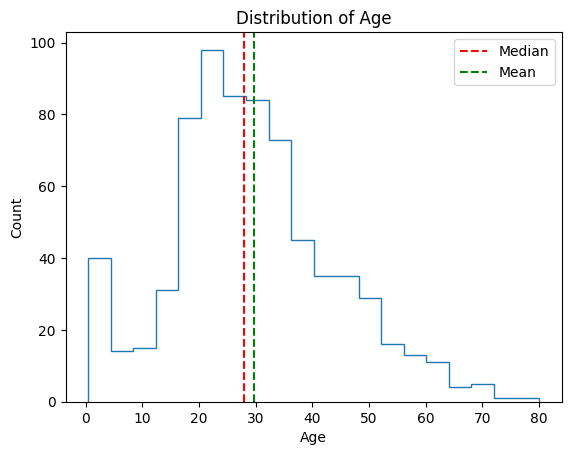

In [12]:
fig, ax = plt.subplots()
ax.hist(titanic_df['Age'], histtype='step', bins=20)
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.set_title('Distribution of Age')
ax.axvline(titanic_df['Age'].median(), c = 'r', linestyle = '--', label = 'Median')
ax.axvline(titanic_df['Age'].mean(), c = 'g', linestyle = '--', label = 'Mean')
ax.legend()
plt.show()

In [13]:
titanic_df['Age'] = titanic_df['Age'].fillna(titanic_df['Age'].median())

In [14]:
print(titanic_df['Age'].mean())
print(titanic_df['Age'].std(ddof=1))

29.36158249158249
13.019696550973194


In [15]:
print(titanic_df['Embarked'].unique())
print(titanic_df['Embarked'].value_counts())

['S' 'C' 'Q' nan]
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


In [17]:
mod_df = titanic_df.dropna(subset=['Embarked'])
mod_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PassengerId             889 non-null    int64  
 1   Survived                889 non-null    int64  
 2   PassengerClass          889 non-null    int64  
 3   Name                    889 non-null    object 
 4   Sex                     889 non-null    object 
 5   Age                     889 non-null    float64
 6   Sibling_Spouse_Count    889 non-null    int64  
 7   Parents_Children_Count  889 non-null    int64  
 8   Ticket                  889 non-null    object 
 9   Fare                    889 non-null    float64
 10  Embarked                889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 83.3+ KB


In [18]:
titanic_df['Embarked'].mode()

0    S
Name: Embarked, dtype: object

In [19]:
embarked_mode = titanic_df['Embarked'].mode().iloc[0]
embarked_mode

'S'

In [20]:
titanic_df['Embarked'] = titanic_df['Embarked'].fillna(embarked_mode)
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PassengerId             891 non-null    int64  
 1   Survived                891 non-null    int64  
 2   PassengerClass          891 non-null    int64  
 3   Name                    891 non-null    object 
 4   Sex                     891 non-null    object 
 5   Age                     891 non-null    float64
 6   Sibling_Spouse_Count    891 non-null    int64  
 7   Parents_Children_Count  891 non-null    int64  
 8   Ticket                  891 non-null    object 
 9   Fare                    891 non-null    float64
 10  Embarked                891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [21]:
titanic_df.to_csv('clean_titanic.csv')